In [64]:
import random
import networkx as nx
import matplotlib.pyplot as plt

In [65]:
def gera_matriz(N, seed):
    random.seed(seed)

    matriz = [[random.randint(1, 3) for _ in range(N)] for _ in range(N)]

    return matriz


def distance(node1, node2):
    return max(abs(node1[0] - node2[0]),(abs(node1[1] - node2[1])))

N = 6
seed = 11

matriz = gera_matriz(N, seed)

G_base = nx.grid_2d_graph(N, N)

G = nx.DiGraph(G_base)


for i in range(N):
    for j in range(N):
        G.nodes[(i, j)]["type"] = matriz[i][j]

position = {(x,y): (y, -x) for x, y in G.nodes()}

nodes_C = [node for node, data in G.nodes(data=True) if data["type"] == 1]
nodes_S = [node for node, data in G.nodes(data=True) if data["type"] == 2]
nodes_T = [node for node, data in G.nodes(data=True) if data["type"] == 3]

successed_path = []
failed_path = []

In [66]:
def path_search(current_node, step, current_path):
    if step == 2: # 2 from circle to nearest square
        candidate_node = nodes_S

    elif step == 3: # 3 from square to nearest triangle (only right or bellow)
        candidate_node = nodes_T
        candidate_node = [t for t in nodes_T if (t[1] > current_node[1] and t[0] == current_node[0]) or (t[0] > current_node[0] and t[1] == current_node[1])]
        print(current_node ,candidate_node)

    elif step == 4: # 4 from triangle to square (only diagonal)
        candidate_node = [s for s in nodes_S if abs(s[0] - current_node[0]) == abs(s[1] - current_node[1]) and s != current_node]

    elif step == 5: # 5 successed
        successed_path.append(current_path)
        return

    if not candidate_node: # no candidate node
        failed_path.append(current_path)
        return

    minimum_dist = min(distance(current_node, c) for c in candidate_node)
    closest_node = [c for c in candidate_node if distance(current_node, c) == minimum_dist]

    for next_node in closest_node:
        path_search(next_node, step + 1, current_path + [next_node])

In [67]:
for circle in nodes_C:
    path_search(circle, 2, [circle])

path_edges = set()
for path in successed_path + failed_path:
    for i in range((len(path))-1):
        path_edges.add((path[i], path[i+1]))

failed_nodes = list(set([c[-1] for c in failed_path]))
succeed_nodes = list(set([c[-1] for c in successed_path]))

(0, 0) [(0, 1), (0, 4), (0, 5), (3, 0), (5, 0)]
(0, 0) [(0, 1), (0, 4), (0, 5), (3, 0), (5, 0)]
(0, 2) [(0, 4), (0, 5), (1, 2), (3, 2), (4, 2), (5, 2)]
(2, 2) [(3, 2), (4, 2), (5, 2)]
(0, 0) [(0, 1), (0, 4), (0, 5), (3, 0), (5, 0)]
(0, 2) [(0, 4), (0, 5), (1, 2), (3, 2), (4, 2), (5, 2)]
(2, 2) [(3, 2), (4, 2), (5, 2)]
(4, 0) [(4, 1), (4, 2), (4, 3), (4, 4), (5, 0)]
(2, 2) [(3, 2), (4, 2), (5, 2)]
(1, 3) [(1, 4), (1, 5), (4, 3)]
(2, 3) [(4, 3)]
(3, 5) []
(3, 5) []
(2, 2) [(3, 2), (4, 2), (5, 2)]
(2, 3) [(4, 3)]
(3, 5) []
(4, 0) [(4, 1), (4, 2), (4, 3), (4, 4), (5, 0)]
(3, 5) []
(3, 5) []
(3, 5) []


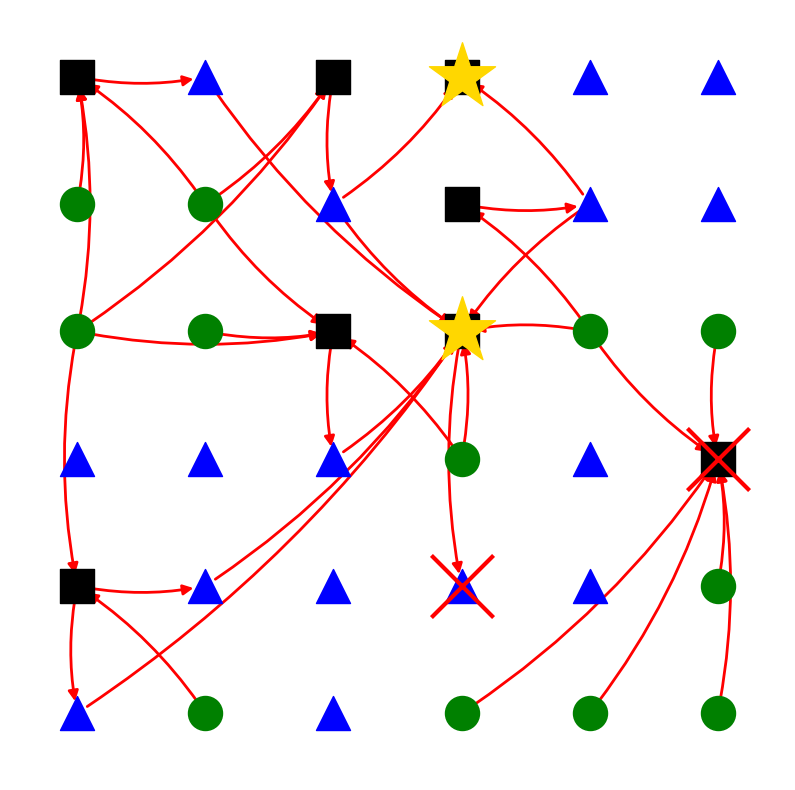

In [68]:
plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_C,
    node_color="green",
    node_size=600,
    node_shape="o"
)

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_S,
    node_color="black",
    node_size=600,
    node_shape="s"
)

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_T, 
    node_color="blue",
    node_size=600,
    node_shape="^"
)


if failed_nodes:
    nx.draw_networkx_nodes(
        G,
        pos=position,
        nodelist=failed_nodes,
        node_color="red",
        node_size=2000,
        node_shape="x",
        linewidths=3
    )
    
if succeed_nodes:
    nx.draw_networkx_nodes(
        G,
        pos=position,
        nodelist=succeed_nodes,
        node_color="gold",
        node_size=2500,
        node_shape="*"
    )

nx.draw_networkx_edges(
    G, 
    pos=position, 
    edgelist=list(path_edges), 
    edge_color="red", 
    width=2,
    arrows=True,
    arrowsize=15,
    connectionstyle="arc3,rad=0.1",
)

plt.axis("off")
plt.show()